Data Cleaning on Airbnb NYC 2019 Dataset   

Internship - Oasis Infobyte (OIBSIP)  
Project 3 Proposal Level 1  
Author - Aniket Mishra  

Objective -  

The objective of this project is to clean and preprocess a raw dataset by identifying and handling missing values, removing duplicate records, standardizing data formats, correcting inconsistencies and detecting potential outliers.

Understanding the Dataset -      

The Airbnb NYC 2019 dataset contains information about Airbnb listings in New York City in 2019. Each row represents one Airbnb listing, while each column provides details of that listing such as its price, location, room type, etc.     

The dataset will be cleaned before performing any further analysis.

In [1]:
# Importing Libraries

import pandas as pd      
import numpy as np  
import matplotlib.pyplot as plt

In [2]:
# Loading Dataset

df = pd.read_csv("D:/Downloads/AB_NYC_2019.csv.zip")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Observation -  

The first five rows of the dataset are displayed above.      
It provides a quick preview before performing any cleaning or analysis.

In [3]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


Observation -  

The last five rows of the dataset are displayed above.     
We can verify that the dataset has been loaded completely.

In [4]:
df.columns = (df.columns.str.replace("_"," ").str.title().str.replace("Id","ID"))

Standardizing Column Names -  

The columns were standardised to improve readability and maintain consistency.  
Underscores(`_`) were replaced with spaces and column names were capitalized. 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              48895 non-null  int64  
 1   Name                            48879 non-null  str    
 2   Host ID                         48895 non-null  int64  
 3   Host Name                       48874 non-null  str    
 4   Neighbourhood Group             48895 non-null  str    
 5   Neighbourhood                   48895 non-null  str    
 6   Latitude                        48895 non-null  float64
 7   Longitude                       48895 non-null  float64
 8   Room Type                       48895 non-null  str    
 9   Price                           48895 non-null  int64  
 10  Minimum Nights                  48895 non-null  int64  
 11  Number Of Reviews               48895 non-null  int64  
 12  Last Review                     38843 non-n

The `info()` function display the structure of the dataset. It helps identify missing values and verify whether each column has the correct data type or not.  

Observation -  

The dataset contains both numerical and categorical columns. Some columns have missing values which can be identified by the non null count. 

In [6]:
df.describe()

,ID,Host ID,Latitude,Longitude,Price,Minimum Nights,Number Of Reviews,Reviews Per Month,Calculated Host Listings Count,Availability 365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


`describe()` function generates summary statistics for all numerical columns in the dataset. It help us understand the distribution of the data and identify unusual values before cleaning.  

Observation -  

1. The count for all numerical values is 48895 except `Reviews Per Month` column as it has lower count as some values are missing.  
2. The `Price` column has a minimum value of "0", which may be an incorrect entry.  
3. The mean is higher that the median(50%) in the `Price` column. It may be because of a potential outlier.

In [7]:
df.isnull().sum()

ID                                    0
Name                                 16
Host ID                               0
Host Name                            21
Neighbourhood Group                   0
Neighbourhood                         0
Latitude                              0
Longitude                             0
Room Type                             0
Price                                 0
Minimum Nights                        0
Number Of Reviews                     0
Last Review                       10052
Reviews Per Month                 10052
Calculated Host Listings Count        0
Availability 365                      0
dtype: int64

Observation -  

We can see the missing values in each column. This helps determine which columns require data cleaning.  

`Name` and `Host Name` columns a small number of missing values, whereas, `Last Review` and `Review Per Month` columns have a significant number of missing values.

In [8]:
df = df.fillna({"Name":"Unknown", "Host Name":"Unknown"})

df["Reviews Per Month"] = df["Reviews Per Month"].fillna(0)

Handle Missing Values -  

The missing values in the `Name` and `Host Name` columns were replaced with `Unknown`and they weren't removed as that would have resulted in unnecesary data loss. This preserves the dataset without deleting any records.  
 
Where as, missing values in `Reviews Per Month` column were replaced with `0` because they represent listings with no reviews which means no reviews per month.

In [9]:
df.isnull().sum()

ID                                    0
Name                                  0
Host ID                               0
Host Name                             0
Neighbourhood Group                   0
Neighbourhood                         0
Latitude                              0
Longitude                             0
Room Type                             0
Price                                 0
Minimum Nights                        0
Number Of Reviews                     0
Last Review                       10052
Reviews Per Month                     0
Calculated Host Listings Count        0
Availability 365                      0
dtype: int64

Observation -   

The missing values in the `Name`, `Host Name` and `Reviews Per Month` columns were successfully handled.  

The missing values in the `last_review` column most likely indicate that the listing has not yet received any reviews, therefore no review date is available.   
Since it is not an error, the missing values were retained.

In [10]:
df.duplicated().sum()

np.int64(0)

Observation -  
    
No duplicate records were found (`0` duplicates). Therefore, no duplicate removal was required.

In [11]:
df["Last Review"] = pd.to_datetime(df["Last Review"])

Observation -  

The `Last Review` column was converted into `datetime` data type from `object` data type. This ensures consistent date handling and makes it suitable for time based analysis. 

In [12]:
# Creating Review Status Column

df["Review Status"] = df["Last Review"].isna().map({True:"Never Reviewed", False:"Reviewed"})

df["Review Status"].value_counts()

Review Status
Reviewed          38843
Never Reviewed    10052
Name: count, dtype: int64

Observation -  

A new column `Review Status` was reated based on `Last Review` column. It shows the count of number of listings that hae been reviewed and those that never have been reviewed. 

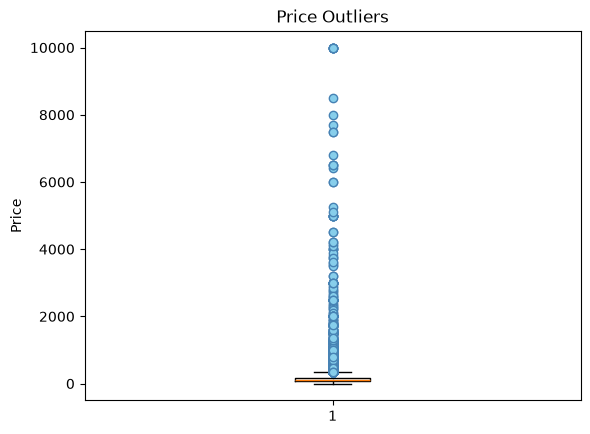

In [28]:
plt.boxplot(df["Price"], flierprops = dict(markerfacecolor = "skyblue", markeredgecolor = "steelblue"))

plt.title("Price Outliers")
plt.ylabel("Price")
plt.show()

A boxplot is used to identify the distribution of data and detect outliers. Outliers are unusually high or low values that differ significantly from the rest of the dataset.  

Observation -  

The median price lies closer to the lower price range, therefore most of the listings are affordable and inexpensive as the data points are concentrated in lower price range. 

In [14]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

Summary -  

Interquartile Range (IQR) method is used to identify potential outliers in the `Price` column.  
It represents the spread of the middle 50% of the data.  
Any value below the lower limit or above the upper limit is considered a potential outlier.

In [15]:
outliers = df[(df["Price"] < lower) | (df["Price"] > upper)]
len(outliers)

2972

Observation -  

The outliers were identified but not removed because they represent genuine high priced listings ratherthan an incorrect number or data errors. That's why they were retained.

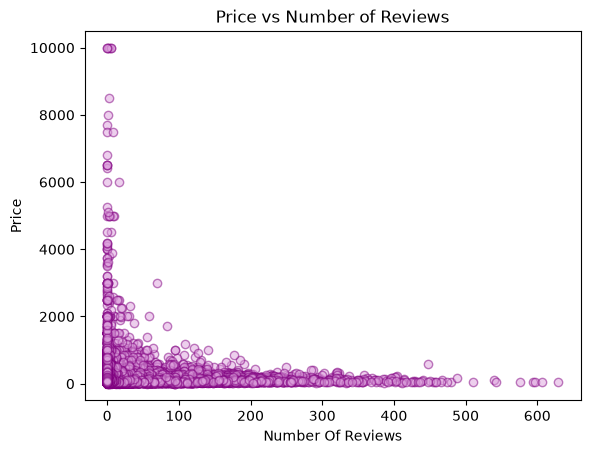

In [32]:
plt.scatter(df["Number Of Reviews"],df["Price"], alpha = 0.5, color = "plum", edgecolors = "purple")
plt.title("Price vs Number of Reviews")

plt.xlabel("Number Of Reviews")
plt.ylabel("Price")
plt.show()

The Scatter Plot shows the relation between `Price` and `Number Of Reviews`.   
Most listings are concentrated in the lower price range, regardless of the number of reviews whereas, some listings have very high prices, appearing as outliers.  

Observation -    

Affordable listings tend to receive more reviews, likely because they are booked more frequently.  
Higher priced listings do not necessarily receive more reviews. They have relatively few reviews, making them stand out as outliers.

In [17]:
df.to_csv("AB_NYC_2019_Cleaned.csv", index=False)

The cleaned dataset is saved as a new CSV file.    
The parameter `index=False` prevents the Dataframe index from being saved as an additional column in the output file.

Conclusion-  

The Dataset was successfully cleaned by identifying and handling missing values, checking for duplicate records, verifying data types and detecting potential outliers using the IQR method and a boxplot.    

Missing values in the `Name` and `Host Name` columns were replaced with `"Unknown"`, while missing values in `Reviews Per Month` were replaced with `0`.   

No duplicate records were found in the dataset. Potential outliers in the `Price` column were identified but retained because they represent genuine luxury listings rather than incorrect data.    

The cleaned dataset was saved and is now ready for further analysis and visualization.